# <span>Worksheet - 5</span>
## <span>Implementation of Convolutional Neural Network using Keras
<small>

**Student Name:** Pratisha Bista  
**ID:** 2408284  
**Group:** L6CG1  

</small>

*   Understand model compilation and training
*   Evaluate and test model performance
*   Make predictions and interpret results



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Example - Simple CNN implemented using Keras


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)

# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])

# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.9618 - loss: 0.1240 - val_accuracy: 0.9852 - val_loss: 0.0417
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9870 - loss: 0.0433 - val_accuracy: 0.9873 - val_loss: 0.0403
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9909 - loss: 0.0284 - val_accuracy: 0.9902 - val_loss: 0.0284
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 33ms/step - accuracy: 0.9935 - loss: 0.0201 - val_accuracy: 0.9901 - val_loss: 0.0339
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9953 - loss: 0.0144 - val_accuracy: 0.9907 - val_loss: 0.0315
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9907 - loss: 0.0315
Test accuracy: 0.9907
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


In [3]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

# Exercise: Implement an End to End CNN Model for classifying fruits in Amazon using TensorFlow and Keras

## Task 1: Data Understanding and Visualization

### 1. Load and visualise data

In [5]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

In [14]:
train_path = "/content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-5/FruitinAmazon/train"

In [15]:
classes = os.listdir(train_path)
print(f"Found {len(classes)} classes: {classes}")

Found 6 classes: ['tucuma', 'cupuacu', 'guarana', 'graviola', 'pupunha', 'acai']


In [16]:
image_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')

sample_images = []
sample_labels = []

# Loop through each class

for class_name in classes:
    class_dir = os.path.join(train_path, class_name)

    all_files = os.listdir(class_dir)

    image_files = []
    for f in all_files:
        f_lower = f.lower()
        if f_lower.endswith(image_exts):
            image_files.append(f)

    if image_files:
        img_file = random.choice(image_files)

        img_path = os.path.join(class_dir, img_file)
        img = Image.open(img_path)

        sample_images.append(img)
        sample_labels.append(class_name)
        print(f"{class_name}: {img_file}")

tucuma: download.jpeg
cupuacu: images (6).jpeg
guarana: images (6).jpeg
graviola: download (5).jpeg
pupunha: download.jpeg
acai: images (8).jpeg


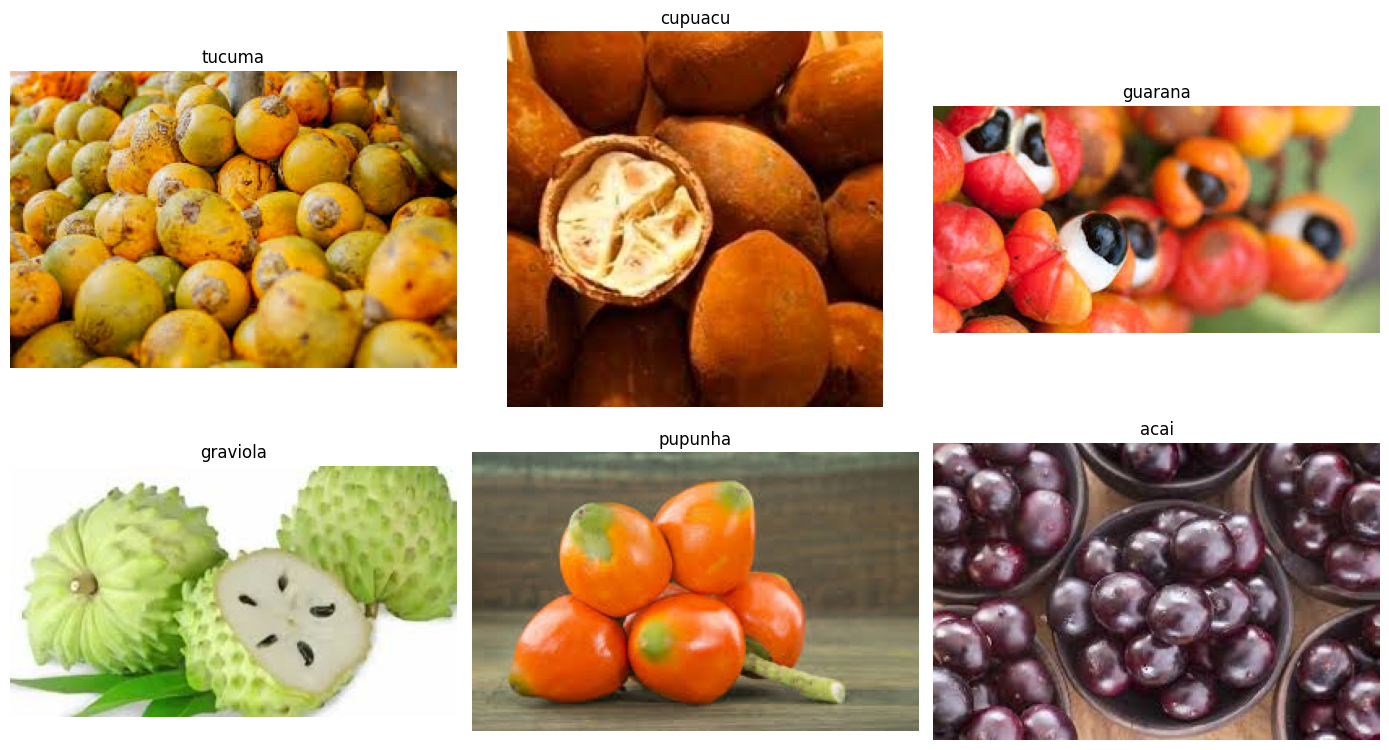

In [18]:
# display one random image from each class

num_images = len(sample_images)
cols = (num_images + 1) // 2

plt.figure(figsize=(14, 8))

for i, (img, label) in enumerate(zip(sample_images, sample_labels)):
    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(label, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

As seen in the images above, a random image from each class has been selected and displayed.

### 2. Check for corrupted image

In [19]:
image_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')

good_count = 0
corrupted_count = 0

for class_name in os.listdir(train_path):
    class_dir = os.path.join(train_path, class_name)

    if not os.path.isdir(class_dir):
        continue

    for filename in os.listdir(class_dir):
        if not filename.lower().endswith(image_exts):
            continue

        file_path = os.path.join(class_dir, filename)
        file_size = os.path.getsize(file_path)

        try:
            with Image.open(file_path) as img:
                img.verify()
            good_count += 1
            status = "GOOD"
        except Exception as e:
            corrupted_count += 1
            status = f"CORRUPTED - {str(e)[:50]}"

        print(f"{status:30} | {class_name:10} | {filename:20} | Size: {file_size} bytes")

print("\n" + "="*70)
print(f"Good images: {good_count}")
print(f"Corrupted images: {corrupted_count}")

GOOD                           | tucuma     | download (6).jpeg    | Size: 6568 bytes
GOOD                           | tucuma     | images (2).jpeg      | Size: 6446 bytes
GOOD                           | tucuma     | download (9).jpeg    | Size: 10906 bytes
GOOD                           | tucuma     | images (6).jpeg      | Size: 7915 bytes
GOOD                           | tucuma     | images (8).jpeg      | Size: 7629 bytes
GOOD                           | tucuma     | images (5).jpeg      | Size: 12824 bytes
GOOD                           | tucuma     | images.jpeg          | Size: 5800 bytes
GOOD                           | tucuma     | download (7).jpeg    | Size: 10000 bytes
GOOD                           | tucuma     | images (7).jpeg      | Size: 8178 bytes
GOOD                           | tucuma     | images (9).jpeg      | Size: 10947 bytes
GOOD                           | tucuma     | download.jpeg        | Size: 15010 bytes
GOOD                           | tucuma     | ima

## Task 2: Loading and Preprocessing Image Data in keras

In [ ]:
import tensorflow as tf

In [21]:
# Parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2  # 80% train, 20% validation

# Create rescaling layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)

# Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply normalization to training dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply normalization to validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Check dataset sizes
print(f"\nNumber of training batches: {len(train_ds)}")
print(f"Number of validation batches: {len(val_ds)}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.

Number of training batches: 3
Number of validation batches: 1


## Task 3 - Simple CNN model with given hyperparameters

In [23]:
from tensorflow.keras import layers, Sequential

num_classes = len(classes)
print(f"Number of classes: {num_classes}")

model = Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu', input_shape=(img_height, img_width, 3)),

    # Pooling Layer 1 (max pooling)
    layers.MaxPooling2D((2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu'),

    # Pooling Layer 2 (max pooling)
    layers.MaxPooling2D((2, 2), strides=2),

    # Flatten - convert 3D to 1D
    layers.Flatten(),

    # Fully Connected Layer 1
    layers.Dense(64, activation='relu'),

    # Fully Connected Layer 2
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

# Show model summary
model.summary()

Number of classes: 6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4 - Compile and train the model

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    'Pratisha_Bista_2408284_best_fruit_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 1.0000 - loss: 0.0064
Epoch 1: val_accuracy improved from None to 0.88889, saving model to Pratisha_Bista_2408284_best_fruit_model.h5



Epoch 1: finished saving model to Pratisha_Bista_2408284_best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 560ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 0.8889 - val_loss: 0.1911
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 1.0000 - loss: 0.0026
Epoch 2: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.8889 - val_loss: 0.2469
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 1.0000 - loss: 0.0012
Epoch 3: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8889 - val_loss: 0.3385
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 1.0000 - loss: 0.0012
Epoch 4: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 528ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8333 - val_loss: 0.4339
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - a

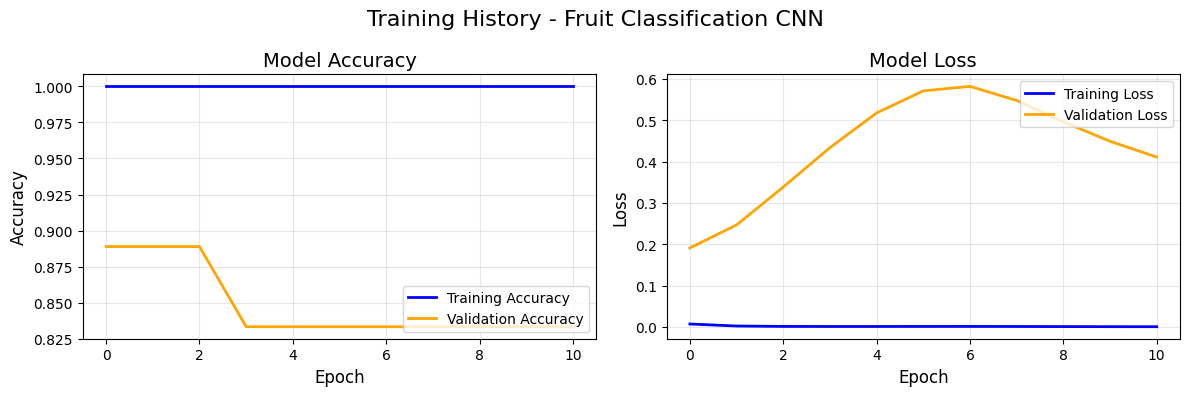

In [36]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.suptitle('Training History - Fruit Classification CNN', fontsize=16)
plt.tight_layout()
plt.savefig('Pratisha_Bista_2408284_training_history.png', dpi=150)
plt.show()

In [31]:
model.save('Pratisha_Bista_2408284_best_fruit_model.h5')
print("Final model saved as 'Pratisha_Bista_2408284_best_fruit_model.h5'")

Final model saved as 'Pratisha_Bista_2408284_best_fruit_model.h5'


## Task 5 - Evaluate the model

In [32]:
test_path = "/content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-5/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

# Normalize test data
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.7667 - loss: 0.9097

Test Loss: 0.9097
Test Accuracy: 0.7667


In [34]:
from tensorflow.keras.models import load_model

loaded_model = load_model('Pratisha_Bista_2408284_best_fruit_model.h5')
print("Model loaded successfully!")

test_loss2, test_acc2 = loaded_model.evaluate(test_ds)
print(f"Loaded model - Test Accuracy: {test_acc2:.4f}")

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 864ms/step - accuracy: 0.7667 - loss: 0.9097
Loaded model - Test Accuracy: 0.7667


## Task 6 - Predictions and Classification Report

In [35]:
from sklearn.metrics import classification_report
import numpy as np

predictions = loaded_model.predict(test_ds)

predicted_labels = np.argmax(predictions, axis=1)

true_labels = np.concatenate([y for x, y in test_ds], axis=0)

print(classification_report(true_labels, predicted_labels, target_names= classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
              precision    recall  f1-score   support

      tucuma       0.57      0.80      0.67         5
     cupuacu       0.62      1.00      0.77         5
     guarana       1.00      0.80      0.89         5
    graviola       1.00      0.40      0.57         5
     pupunha       0.83      1.00      0.91         5
        acai       1.00      0.60      0.75         5

    accuracy                           0.77        30
   macro avg       0.84      0.77      0.76        30
weighted avg       0.84      0.77      0.76        30



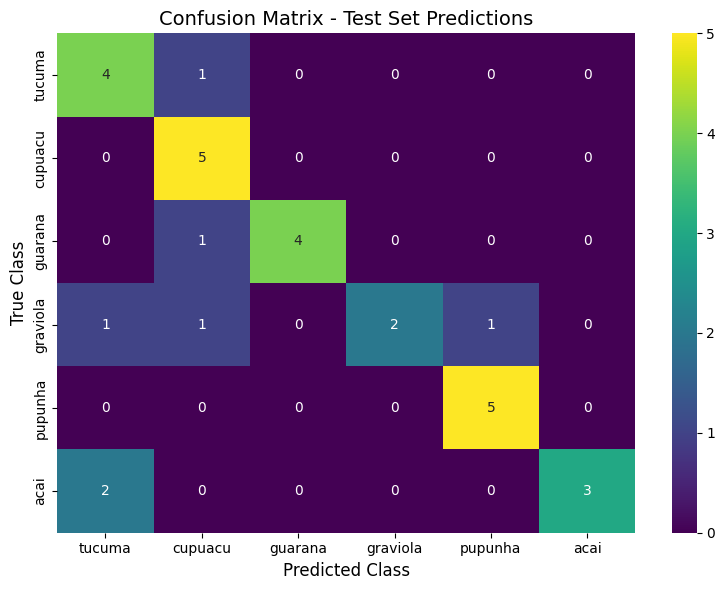


PER-CLASS ACCURACY ON TEST SET

tucuma      : 4/5 = 80.00%
cupuacu     : 5/5 = 100.00%
guarana     : 4/5 = 80.00%
graviola    : 2/5 = 40.00%
pupunha     : 5/5 = 100.00%
acai        : 3/5 = 60.00%


In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Test Set Predictions', fontsize=14)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.savefig('Pratisha_Bista_2408284_confusion_matrix.png', dpi=150)
plt.show()

print("\nPER-CLASS ACCURACY ON TEST SET\n")
for i, fruit in enumerate(classes):
    correct = cm[i, i]
    total = np.sum(cm[i, :])
    acc = correct / total if total > 0 else 0
    print(f"{fruit:12}: {correct}/{total} = {acc:.2%}")